# Computational Aspects of Ramanujan Summation

This notebook demonstrates the computation of various infinite series sums using tail approximations. Each example is run in its own cell so you can capture the output (both numerical and plots) for your Thesis.

In [30]:
# Install and update required packages
import Pkg
Pkg.activate(".")
Pkg.instantiate()

# Add/update required packages
Pkg.add("SymPy")
Pkg.add("Plots")
Pkg.add("Printf")
Pkg.add("SpecialFunctions")
Pkg.update()

  Activating project at `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
    Updating registry at `~/.julia/registries/General.toml`

## Module Definition: Analytictail

The following cell defines the module `Analytictail` which contains all functions needed for computing the infinite series sums using Euler–Maclaurin (for non‐alternating series) and Euler–Boole (for alternating series) tail approximations. Note that we export the symbols `run_example` and `x_` so they can be used directly from the Main module.

In [31]:
module Analytictail

using SymPy
using Plots
using Printf
using SpecialFunctions  # For coth, etc.

export run_example, sum_infinite_series, plot_error_vs_m, x_

##########################################################
# 1) Setup
##########################################################
setprecision(256)  # Very high precision for demonstration
gr()

# Partial-sum cutoffs
const Kset = [1, 2, 3, 4]
# Max correction terms
const m_max = 30

# We'll store Bernoulli / Euler polynomials in caches
const bernoulliCache = Dict{Int, Vector{Rational{BigInt}}}()
const eulerPolyCache = Dict{Tuple{Int, Float64}, Dict{Int, Float64}}()

##########################################################
# 2) Bernoulli numbers (caching)
##########################################################
function BernoulliListCached(n::Int)::Vector{Rational{BigInt}}
    if haskey(bernoulliCache, n)
        return bernoulliCache[n]
    end
    A = Vector{Rational{BigInt}}(undef, n+1)
    B = similar(A)
    for mm in 0:n
        A[mm+1] = 1 // (mm+1)
        for j in mm:-1:1
            A[j] = j*(A[j]-A[j+1])
        end
        B[mm+1] = A[1]
    end
    bernoulliCache[n] = B
    return B
end

##########################################################
# 3) Euler polynomials (for Euler–Boole)
##########################################################
function euler_polynomials_cached(max_n::Int, x_val::Float64)::Dict{Int, Float64}
    key = (max_n, x_val)
    if haskey(eulerPolyCache, key)
        return eulerPolyCache[key]
    end

    t = SymPy.symbols("t")
    expr = (2*SymPy.exp(x_val*t)) / (SymPy.exp(t)+1)
    out = Dict{Int, Float64}()
    for n in 0:max_n
        try
            ser = expr.series(t, 0, n+1).expand()
            coeff_n = factorial(big(n))*ser.coeff(t,n)
            out[n] = float(coeff_n)
        catch
            @warn "Failed Euler poly E_$n($x_val)"
            out[n] = 0.0
        end
    end
    eulerPolyCache[key] = out
    return out
end

##########################################################
# 4) Utility: safe_real_float
##########################################################
function safe_real_float(expr)::Float64
    try
        val = expr.evalf()
        return float(SymPy.real(val))
    catch
        return NaN
    end
end

##########################################################
# 5) Euler–Boole tail approximation (ALTERNATING)
##########################################################
function euler_boole_infinite_tail(f::Sym, m::Int)::Float64
    local x_ = SymPy.symbols("x")
    f1 = safe_real_float(f.subs(x_, 1))

    e_dict = euler_polynomials_cached(m, 1.0)
    sum_corr = 0.0
    for j in 1:m
        d_expr = diff(f, x_, j).subs(x_, 1)
        d_val  = safe_real_float(d_expr)
        e_j    = e_dict[j]
        sum_corr += (e_j / factorial(big(j))) * d_val
    end
    return 0.5*f1 + sum_corr
end

##########################################################
# 6) Euler–Maclaurin tail approximation (NON-ALTERNATING)
##########################################################
function euler_maclaurin_infinite_tail(f::Sym, m::Int)::Float64
    local x_ = SymPy.symbols("x")
    
    integral_sym = try
        SymPy.integrate(f, (x_, 1, SymPy.oo))
    catch
        nothing
    end

    if integral_sym === nothing || integral_sym == SymPy.oo || integral_sym == -SymPy.oo
        @warn "Analytical integration failed or diverged; setting integral to 0.0."
        integral_val = 0.0
    else
        integral_val = safe_real_float(integral_sym)
    end

    half_term = 0.5 * safe_real_float(f.subs(x_, 1))
    
    Blist = BernoulliListCached(2*m)
    sum_corr = 0.0
    for j in 1:m
        dorder = 2*j - 1
        dexpr  = diff(f, x_, dorder).subs(x_, 1)
        dval   = safe_real_float(dexpr)
        b_2j   = float(Blist[2*j+1])
        denom  = factorial(big(2*j))
        sum_corr += (b_2j / denom) * dval
    end

    return integral_val + half_term - sum_corr
end

##########################################################
# 7) sum_infinite_series = partial sum + tail
##########################################################
function sum_infinite_series(f::Sym, k::Int, m::Int, alt::Bool)::Float64
    local x_ = SymPy.symbols("x")

    S_k = 0.0
    for n in 1:k
        S_k += safe_real_float(f.subs(x_, n))
    end

    f_tail = f.subs(x_, x_ + k)

    if alt
        return S_k + euler_boole_infinite_tail(f_tail, m)
    else
        return S_k + euler_maclaurin_infinite_tail(f_tail, m)
    end
end

##########################################################
# 8) plot_error_vs_m
##########################################################
function plot_error_vs_m(f::Sym, desc::String, known_val::Float64, alt::Bool)
    p = plot(
        title = desc * " : log10(|error|) vs. m",
        xlabel = "m (derivative expansions)",
        ylabel = "log10(|error|)",
        legend = :topright
    )

    for k in Kset
        local logerrs = Float64[]
        println("\n$desc => alt=$alt, k=$k => exact=$known_val")
        # Print Markdown table header
        println("| m | Approx | Error |")
        println("|---|---|---|")
        for mm in 1:m_max
            approx = sum_infinite_series(f, k, mm, alt)
            err = abs(approx - known_val)
            # Print each row in Markdown table format
            @printf("| %2d | %.16e | %.16e |\n", mm, approx, err)
            push!(logerrs, log10(max(err, 1e-300)))
        end
        plot!(p, 1:m_max, logerrs, label="k=$k", linewidth=2)
    end

    # Create the 'plots' directory if it doesn't exist
    if !isdir("plots")
        mkdir("plots")
    end

    # Sanitize the description for a valid filename (replace invalid characters)
    safe_desc = replace(desc, r"[^a-zA-Z0-9\-_\.]" => "")
    # Save the plot to the 'plots' folder
    savefig(p, joinpath("plots", "$(safe_desc).png"))

    display(p)
end

function run_example(f::Sym, desc::String, known_val::Float64, alt::Bool)
    println("\n=== run_example: $desc")
    plot_error_vs_m(f, desc, known_val, alt)
end


# Export x_ for use in Main
const x_ = SymPy.symbols("x")

end # module

Main.Analytictail

In [32]:
# Import the module into Main
using .Analytictail

In [33]:
# Import SymPy into Main so that `Sym` is defined
using SymPy

In [34]:
# Setup common constants for examples
zeta5_approx = 1.03692775514337
eta3_approx = 0.9015426773696955
alt_sqrt_approx = -0.6048986434

-0.6048986434

### Example 1: Euler Macheroni: sum(1/n)


=== run_example: Euler Macheroni: sum(1/n)

Euler Macheroni: sum(1/n) => alt=false, k=1 => exact=0.57721
| m | Approx | Error |
|---|---|---|
|  1 | 1.2708333333333333e+00 | 6.9362333333333326e-01 |
|  2 | 1.2703125000000000e+00 | 6.9310249999999995e-01 |
|  3 | 1.2703745039682539e+00 | 6.9316450396825391e-01 |
|  4 | 1.2703582279265873e+00 | 6.9314822792658726e-01 |
|  5 | 1.2703656261273448e+00 | 6.9315562612734483e-01 |
|  6 | 1.2703604765189238e+00 | 6.9315047651892381e-01 |
|  7 | 1.2703655627819446e+00 | 6.9315556278194457e-01 |


┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analy

|  8 | 1.2703587991740968e+00 | 6.9314879917409677e-01 |
|  9 | 1.2703704490853296e+00 | 6.9316044908532959e-01 |
| 10 | 1.2703452184753203e+00 | 6.9313521847532034e-01 |
| 11 | 1.2704123238031477e+00 | 6.9320232380314772e-01 |
| 12 | 1.2701972994185060e+00 | 6.9298729941850601e-01 |
| 13 | 1.2710142940756253e+00 | 6.9380429407562527e-01 |
| 14 | 1.2673823713841215e+00 | 6.9017237138412146e-01 |
| 15 | 1.2860578996614740e+00 | 7.0884789966147399e-01 |
| 16 | 1.1760722268574988e+00 | 5.9886222685749879e-01 |


┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analy

| 17 | 1.9115682111741084e+00 | 1.3343582111741084e+00 |
| 18 | -3.6309552384103512e+00 | 4.2081652384103512e+00 |
| 19 | 4.3120166531165502e+01 | 4.2542956531165501e+01 |
| 20 | -3.9563325031472027e+02 | 3.9621046031472025e+02 |
| 21 | 4.1610058406815515e+03 | 4.1604286306815511e+03 |
| 22 | -4.7951583123810997e+04 | 4.7952160333811000e+04 |
| 23 | 6.0546192994910164e+05 | 6.0546135273910163e+05 |
| 24 | -8.3404387734500226e+06 | 8.3404393506600223e+06 |


...

┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analy

| 15 | 2.1866535773356430e+00 | 1.6094435773356430e+00 |
| 16 | 2.1866535773356226e+00 | 1.6094435773356226e+00 |
| 17 | 2.1866535773356444e+00 | 1.6094435773356444e+00 |
| 18 | 2.1866535773356182e+00 | 1.6094435773356182e+00 |
| 19 | 2.1866535773356537e+00 | 1.6094435773356537e+00 |
| 20 | 2.1866535773356004e+00 | 1.6094435773356004e+00 |
| 21 | 2.1866535773356888e+00 | 1.6094435773356888e+00 |
| 22 | 2.1866535773355276e+00 | 1.6094435773355276e+00 |


┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analy

| 23 | 2.1866535773358509e+00 | 1.6094435773358509e+00 |
| 24 | 2.1866535773351421e+00 | 1.6094435773351421e+00 |
| 25 | 2.1866535773368314e+00 | 1.6094435773368314e+00 |
| 26 | 2.1866535773324673e+00 | 1.6094435773324673e+00 |
| 27 | 2.1866535773446532e+00 | 1.6094435773446532e+00 |
| 28 | 2.1866535773079829e+00 | 1.6094435773079829e+00 |
| 29 | 2.1866535774265818e+00 | 1.6094435774265818e+00 |


┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analy

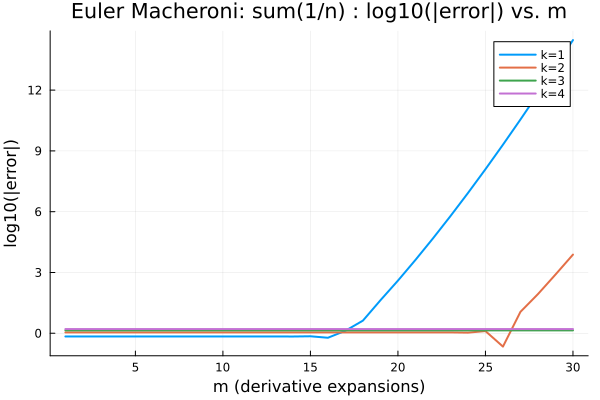

| 30 | 2.1866535770153739e+00 | 1.6094435770153739e+00 |


In [35]:
run_example(1/x_, "Euler Macheroni: sum(1/n)", 0.57721, false)

### Example 2: Basel: sum(1/n²) = π²/6


=== run_example: Basel: sum(1/n²) = π²/6

Basel: sum(1/n²) = π²/6 => alt=false, k=1 => exact=1.6449340668482264
| m | Approx | Error |
|---|---|---|
|  1 | 1.6458333333333335e+00 | 8.9926648510707530e-04 |
|  2 | 1.6447916666666667e+00 | 1.4240018155975420e-04 |
|  3 | 1.6449776785714287e+00 | 4.3611723202330310e-05 |
|  4 | 1.6449125744047619e+00 | 2.1492443464499189e-05 |
|  5 | 1.6449495654085498e+00 | 1.5498560323345956e-05 |
|  6 | 1.6449186677580232e+00 | 1.5399090203205290e-05 |
|  7 | 1.6449542715991692e+00 | 2.0204750942776073e-05 |
|  8 | 1.6449001627363855e+00 | 3.3904111840898921e-05 |
|  9 | 1.6450050119374828e+00 | 7.0945089256424509e-05 |
| 10 | 1.6447527058373890e+00 | 1.8136101083743306e-04 |
| 11 | 1.6454908644434898e+00 | 5.5679759526339190e-04 |
| 12 | 1.6429105718277914e+00 | 2.0234950204349733e-03 |
| 13 | 1.6535315023703399e+00 | 8.5974355221134502e-03 |
| 14 | 1.6026845846892863e+00 | 4.2249482158940088e-02 |
| 15 | 1.8828175088495742e+00 | 2.3788344200134781e-

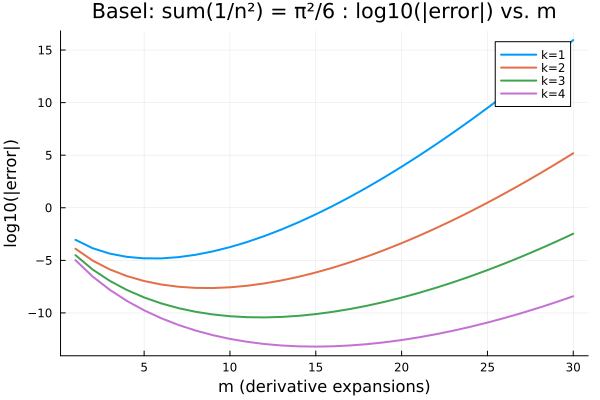

In [36]:
run_example(1/x_^2, "Basel: sum(1/n²) = π²/6", float(pi^2/6), false)

### Example 3: Zeta(3): sum(1/n³) ≈ 1.20206


=== run_example: Zeta(3): sum(1/n³) ≈ 1.20206

Zeta(3): sum(1/n³) ≈ 1.20206 => alt=false, k=1 => exact=1.202056903159594
| m | Approx | Error |
|---|---|---|
|  1 | 1.2031250000000000e+00 | 1.0680968404059854e-03 |
|  2 | 1.2018229166666667e+00 | 2.3398649292727391e-04 |
|  3 | 1.2021484375000000e+00 | 9.1534340405985404e-05 |
|  4 | 1.2020019531249999e+00 | 5.4950034594103414e-05 |
|  5 | 1.2021036783854167e+00 | 4.6775225822637267e-05 |
|  6 | 1.2020032610212055e+00 | 5.3642138388543259e-05 |
|  7 | 1.2021367754255023e+00 | 7.9872265908331741e-05 |
|  8 | 1.2019068127586727e+00 | 1.5009040092128778e-04 |
|  9 | 1.2024048464638846e+00 | 3.4794330429055442e-04 |
| 10 | 1.2010802394383913e+00 | 9.7666372120275291e-04 |
| 11 | 1.2053246514234708e+00 | 3.2677482638767685e-03 |
| 12 | 1.1891978225753559e+00 | 1.2859080584238125e-02 |
| 13 | 1.2608891037375582e+00 | 5.8832200577964233e-02 |
| 14 | 8.9224895054992082e-01 | 3.0980795260967320e-01 |
| 15 | 3.0632791127921517e+00 | 1.861222209

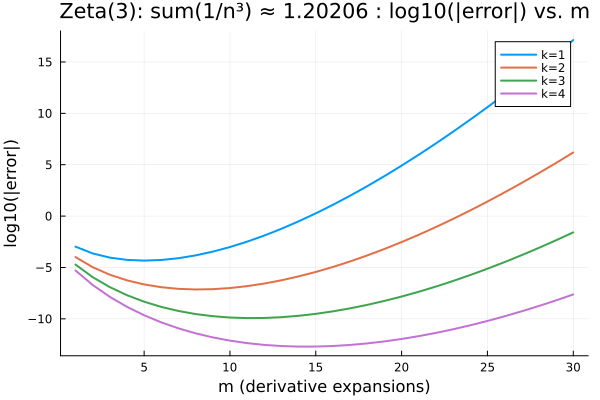

In [37]:
run_example(1/x_^3, "Zeta(3): sum(1/n³) ≈ 1.20206", 1.202056903159594, false)

### Example 4: Zeta(4): sum(1/n⁴) = π⁴/90


=== run_example: Zeta(4): sum(1/n⁴) = π⁴/90

Zeta(4): sum(1/n⁴) = π⁴/90 => alt=false, k=1 => exact=1.0823232337111381
| m | Approx | Error |
|---|---|---|
|  1 | 1.0833333333333333e+00 | 1.0100996221951153e-03 |
|  2 | 1.0820312500000000e+00 | 2.9198371113814403e-04 |
|  3 | 1.0824652777777777e+00 | 1.4204406663953506e-04 |
|  4 | 1.0822211371527777e+00 | 1.0209655836046494e-04 |
|  5 | 1.0824245876736112e+00 | 1.0135396247301642e-04 |
|  6 | 1.0821902804904513e+00 | 1.3295322068684889e-04 |
|  7 | 1.0825463189019098e+00 | 2.2308519077163247e-04 |
|  8 | 1.0818564309014214e+00 | 4.6680280971678201e-04 |
|  9 | 1.0835165432521274e+00 | 1.1933095409892847e-03 |
| 10 | 1.0786596508253188e+00 | 3.6635828858193609e-03 |
| 11 | 1.0956372987656366e+00 | 1.3314065054498503e-02 |
| 12 | 1.0257543737571391e+00 | 5.6568859953999073e-02 |
| 13 | 1.3603136858474167e+00 | 2.7799045213627860e-01 |
| 14 | -4.8288708009077075e-01 | 1.5652103138019089e+00 |
| 15 | 1.1095940451867797e+01 | 1.00136172181

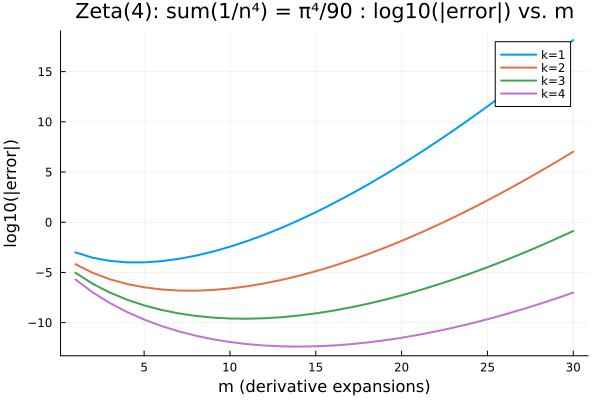

In [38]:
run_example(1/x_^4, "Zeta(4): sum(1/n⁴) = π⁴/90", float(pi^4/90), false)

### Example 5: Zeta(5): sum(1/n⁵) ≈ 1.03693


=== run_example: Zeta(5): sum(1/n⁵) ≈ 1.03693

Zeta(5): sum(1/n⁵) ≈ 1.03693 => alt=false, k=1 => exact=1.03692775514337
| m | Approx | Error |
|---|---|---|
|  1 | 1.0377604166666667e+00 | 8.3266152329675158e-04 |
|  2 | 1.0366210937500000e+00 | 3.0666139336998910e-04 |
|  3 | 1.0371093750000000e+00 | 1.8161985663001090e-04 |
|  4 | 1.0367736816406250e+00 | 1.5407350274498910e-04 |
|  5 | 1.0371042887369792e+00 | 1.7653359360925158e-04 |
|  6 | 1.0366649627685547e+00 | 2.6279237481530160e-04 |
|  7 | 1.0374215443929036e+00 | 4.9378924953358272e-04 |
|  8 | 1.0357830603917439e+00 | 1.1446947516260408e-03 |
|  9 | 1.0401408553123475e+00 | 3.2131001689774674e-03 |
| 10 | 1.0261772895852725e+00 | 1.0750465558097444e-02 |
| 11 | 1.0792324393987656e+00 | 4.2304684255395575e-02 |
| 12 | 8.4337756749508641e-01 | 1.9355018764828358e-01 |
| 13 | 2.0561550738223433e+00 | 1.0192273186789733e+00 |
| 14 | -5.0862478941881344e+00 | 6.1231756493315039e+00 |
| 15 | 4.2676415675140952e+01 | 4.163948791

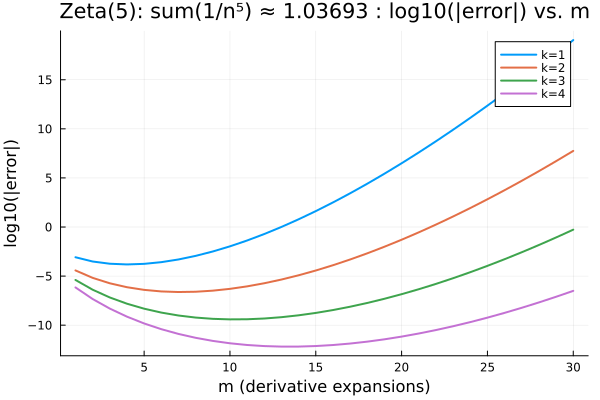

In [39]:
run_example(1/x_^5, "Zeta(5): sum(1/n⁵) ≈ 1.03693", zeta5_approx, false)

### Example 6: Zeta(6): sum(1/n⁶) = π⁶/945


=== run_example: Zeta(6): sum(1/n⁶) = π⁶/945

Zeta(6): sum(1/n⁶) = π⁶/945 => alt=false, k=1 => exact=1.017343061984449
| m | Approx | Error |
|---|---|---|
|  1 | 1.0179687500000001e+00 | 6.2568801555107356e-04 |
|  2 | 1.0170572916666667e+00 | 2.8577031778231898e-04 |
|  3 | 1.0175455729166667e+00 | 2.0251093221768102e-04 |
|  4 | 1.0171427408854166e+00 | 2.0032109903245221e-04 |
|  5 | 1.0176055908203125e+00 | 2.6252883586352915e-04 |
|  6 | 1.0169026692708334e+00 | 4.4039271361562271e-04 |
|  7 | 1.0182645161946615e+00 | 9.2145421021250229e-04 |
|  8 | 1.0149875481923420e+00 | 2.3555137921069669e-03 |
|  9 | 1.0245746970176697e+00 | 7.2316350332206625e-03 |
| 10 | 9.9106213927268982e-01 | 2.6280922711759191e-02 |
| 11 | 1.1290055287877718e+00 | 1.1166246680332281e-01 |
| 12 | 4.6861188745747018e-01 | 5.4873117452697884e-01 |
| 13 | 4.1069444064392400e+00 | 3.0896013444547910e+00 |
| 14 | -1.8748745091194287e+01 | 1.9766088153178735e+01 |
| 15 | 1.4364431104452461e+02 | 1.4262696798

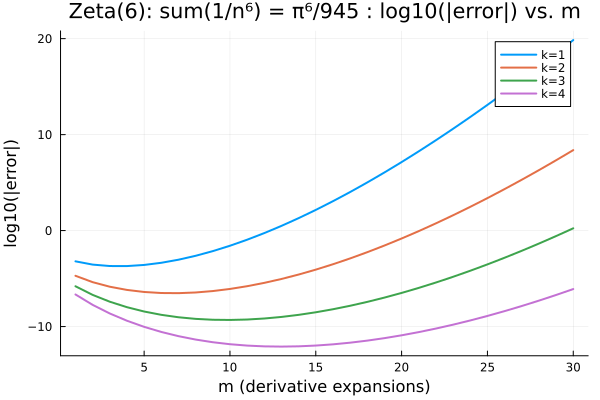

In [40]:
run_example(1/x_^6, "Zeta(6): sum(1/n⁶) = π⁶/945", float(pi^6/945), false)

### Example 7: sum(e⁻ⁿ): 1/(e-1)


=== run_example: sum(e⁻ⁿ): 1/(e-1)

sum(e⁻ⁿ): 1/(e-1) => alt=false, k=1 => exact=0.5819767068693265
| m | Approx | Error |
|---|---|---|
|  1 | 5.8216030629607918e-01 | 1.8359942675272301e-04 |
|  2 | 5.8197234062491709e-01 | 4.3662444093595099e-06 |
|  3 | 5.8197681599804008e-01 | 1.0912871362123155e-07 |
|  4 | 5.8197670411371205e-01 | 2.7556144033269447e-09 |
|  5 | 5.8197670693907377e-01 | 6.9747319031421284e-11 |
|  6 | 5.8197670686756009e-01 | 1.7663648321786241e-12 |
|  7 | 5.8197670686937120e-01 | 4.4741987892393809e-14 |
|  8 | 5.8197670686932534e-01 | 1.1102230246251565e-15 |
|  9 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 10 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 11 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 12 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 13 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 14 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 15 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 16 | 

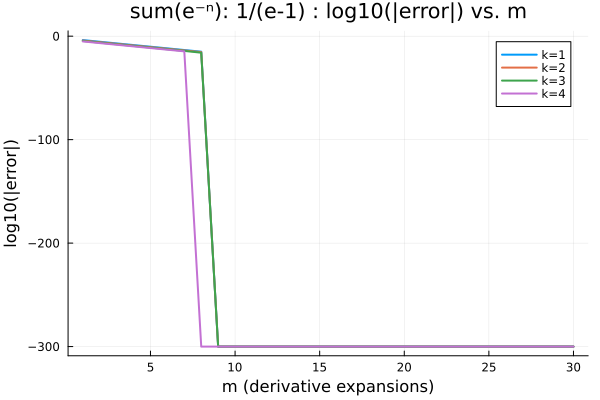

In [41]:
run_example(exp(-x_), "sum(e⁻ⁿ): 1/(e-1)", 1/(exp(1)-1), false)

### Example 8: sum(2⁻ⁿ) = 1


=== run_example: sum(2⁻ⁿ) = 1

sum(2⁻ⁿ) = 1 => alt=false, k=1 => exact=1.0
| m | Approx | Error |
|---|---|---|
|  1 | 1.0001143264839065e+00 | 1.1432648390652389e-04 |
|  2 | 9.9999869292418797e-01 | 1.3070758120292680e-06 |
|  3 | 1.0000000156978137e+00 | 1.5697813715576103e-08 |
|  4 | 9.9999999980954923e-01 | 1.9045076626866830e-10 |
|  5 | 1.0000000000023159e+00 | 2.3159252293680765e-12 |
|  6 | 9.9999999999997180e-01 | 2.8199664825478976e-14 |
|  7 | 1.0000000000000004e+00 | 4.4408920985006262e-16 |
|  8 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
|  9 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 10 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 11 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 12 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 13 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 14 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 15 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 16 | 1.0000000000000000e+00 | 

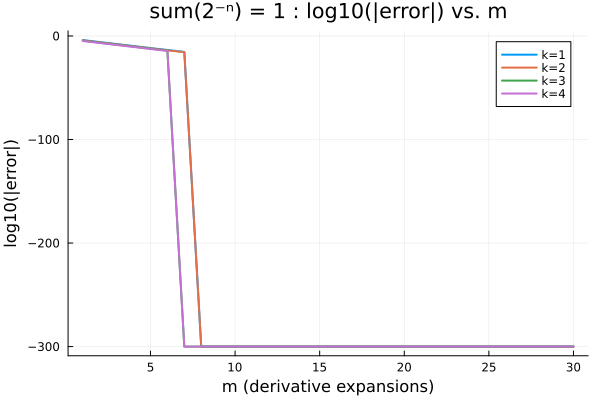

In [42]:
run_example((Sym(2))^(-x_), "sum(2⁻ⁿ) = 1", 1.0, false)

### Example 9: sum(1/(n+1)²) = ζ(2)-1


=== run_example: sum(1/(n+1)²) = ζ(2)-1

sum(1/(n+1)²) = ζ(2)-1 => alt=false, k=1 => exact=0.6449340668482264
| m | Approx | Error |
|---|---|---|
|  1 | 6.4506172839506171e-01 | 1.2766154683530040e-04 |
|  2 | 6.4492455418381334e-01 | 9.5126644130694160e-06 |
|  3 | 6.4493544102597600e-01 | 1.3741777495912544e-06 |
|  4 | 6.4493374751719512e-01 | 3.1933103128434226e-07 |
|  5 | 6.4493417517092766e-01 | 1.0832270125327170e-07 |
|  6 | 6.4493401641165926e-01 | 5.0436567144984679e-08 |
|  7 | 6.4493409771866517e-01 | 3.0870438760821628e-08 |
|  8 | 6.4493404280037558e-01 | 2.4047850821773409e-08 |
|  9 | 6.4493409009711522e-01 | 2.3248888814109137e-08 |
| 10 | 6.4493403951333161e-01 | 2.7334894792119258e-08 |
| 11 | 6.4493410528679784e-01 | 3.8438571436927305e-08 |
| 12 | 6.4493400310171922e-01 | 6.3746507183992662e-08 |
| 13 | 6.4493419004014207e-01 | 1.2319191566856347e-07 |
| 14 | 6.4493379228287895e-01 | 2.7456534745784467e-07 |
| 15 | 6.4493476622942980e-01 | 6.9938120339507748e-07

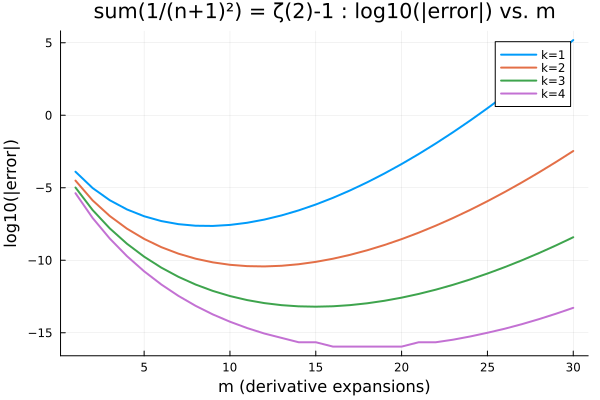

In [43]:
run_example(1/(x_+1)^2, "sum(1/(n+1)²) = ζ(2)-1", float(pi^2/6 - 1.0), false)

### Example 10: sum(1/[n(n+1)]) = 1


=== run_example: sum(1/[n(n+1)]) = 1

sum(1/[n(n+1)]) = 1 => alt=false, k=1 => exact=1.0
| m | Approx | Error |
|---|---|---|
|  1 | 1.0003725155155718e+00 | 3.7251551557182516e-04 |
|  2 | 9.9995456284067463e-01 | 4.5437159325367737e-05 |
|  3 | 1.0000111233878473e+00 | 1.1123387847256083e-05 |
|  4 | 9.9999548241197345e-01 | 4.5175880265535540e-06 |
|  5 | 1.0000027523166113e+00 | 2.7523166112874975e-06 |
|  6 | 9.9999764239800726e-01 | 2.3576019927418201e-06 |
|  7 | 1.0000027112380985e+00 | 2.7112380984739559e-06 |
|  8 | 9.9999595792742968e-01 | 4.0420725703205207e-06 |
|  9 | 1.0000075999558726e+00 | 7.5999558726280725e-06 |
| 10 | 9.9998237693343084e-01 | 1.7623066569161239e-05 |
| 11 | 1.0000494732921492e+00 | 4.9473292149215808e-05 |
| 12 | 9.9983446168064249e-01 | 1.6553831935750551e-04 |
| 13 | 1.0006514347679436e+00 | 6.5143476794360389e-04 |
| 14 | 9.9701955469328940e-01 | 2.9804453067105996e-03 |
| 15 | 1.0156949855759869e+00 | 1.5694985575986919e-02 |
| 16 | 9.057095676

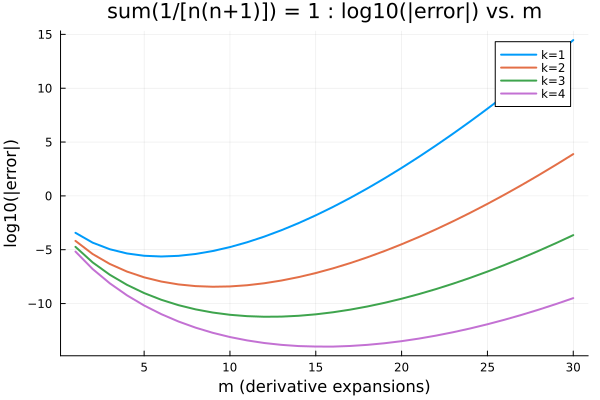

In [44]:
run_example(1/(x_*(x_+1)), "sum(1/[n(n+1)]) = 1", 1.0, false)

### Example 11: sum[(-1)^(n+1)/n] = ln2


=== run_example: sum[(-1)^(n+1)/n] = ln2

sum[(-1)^(n+1)/n] = ln2 => alt=true, k=1 => exact=0.6931471805599453
| m | Approx | Error |
|---|---|---|
|  1 | 8.7500000000000000e-01 | 1.8185281944005471e-01 |
|  2 | 8.7500000000000000e-01 | 1.8185281944005471e-01 |
|  3 | 1.1678001375340425e+00 | 4.7465295697409726e-01 |
|  4 | 1.1678001375340425e+00 | 4.7465295697409726e-01 |
|  5 | 1.5287390845691173e+00 | 8.3559190400917205e-01 |
|  6 | 1.5287390845691173e+00 | 8.3559190400917205e-01 |
|  7 | 1.8545997992983509e+00 | 1.1614526187384056e+00 |
|  8 | 1.8545997992983509e+00 | 1.1614526187384056e+00 |
|  9 | 2.1722893944916359e+00 | 1.4791422139316905e+00 |
| 10 | 2.1722893944916359e+00 | 1.4791422139316905e+00 |
| 11 | 2.4016490717262555e+00 | 1.7085018911663101e+00 |
| 12 | 2.4016490717262551e+00 | 1.7085018911663097e+00 |
| 13 | 2.8125054891127350e+00 | 2.1193583085527896e+00 |
| 14 | 2.8125054891127346e+00 | 2.1193583085527892e+00 |
| 15 | 2.1468296134491651e+00 | 1.4536824328892197e+0

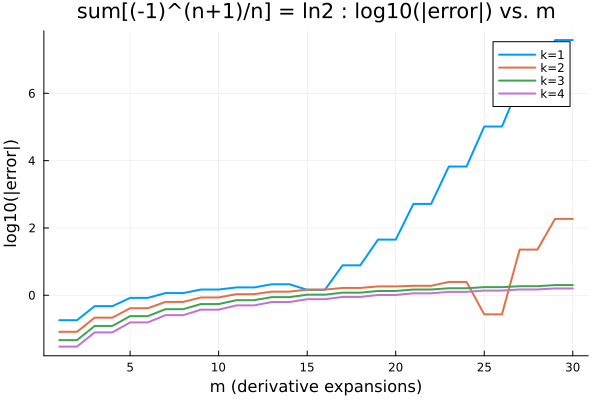

In [45]:
run_example(-cos(pi*x_)/x_, "sum[(-1)^(n+1)/n] = ln2", log(2), true)

### Example 12: sum[(-1)^(n+1)/n²] = π²/12


=== run_example: sum[(-1)^(n+1)/n²] = π²/12

sum[(-1)^(n+1)/n²] = π²/12 => alt=true, k=1 => exact=0.8224670334241132
| m | Approx | Error |
|---|---|---|
|  1 | 1.0000000000000000e+00 | 1.7753296657588680e-01 |
|  2 | 1.0000000000000000e+00 | 1.7753296657588680e-01 |
|  3 | 1.2771751375340425e+00 | 4.5470810410992935e-01 |
|  4 | 1.2771751375340425e+00 | 4.5470810410992935e-01 |
|  5 | 1.4995265158020961e+00 | 6.7705948237798286e-01 |
|  6 | 1.4995265158020961e+00 | 6.7705948237798286e-01 |
|  7 | 1.5891388911215230e+00 | 7.6667185769740975e-01 |
|  8 | 1.5891388911215230e+00 | 7.6667185769740975e-01 |
|  9 | 1.7434176842617357e+00 | 9.2095065083762251e-01 |
| 10 | 1.7434176842617357e+00 | 9.2095065083762251e-01 |
| 11 | 1.5429118531903594e+00 | 7.2044481976624619e-01 |
| 12 | 1.5429118531903585e+00 | 7.2044481976624530e-01 |
| 13 | 2.7460709793183629e+00 | 1.9236039458942495e+00 |
| 14 | 2.7460709793183611e+00 | 1.9236039458942478e+00 |
| 15 | -4.3196428113085892e+00 | 5.142109844732

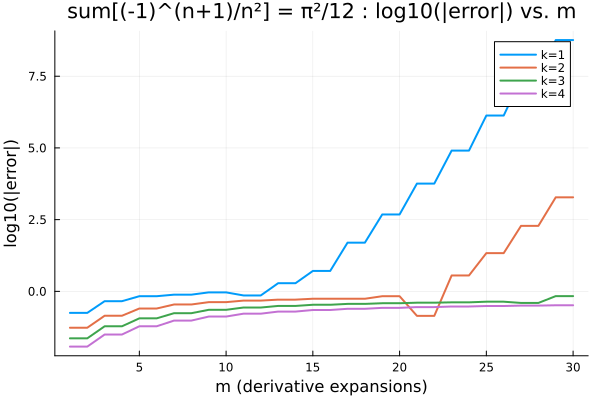

In [46]:
run_example(-cos(pi*x_)/x_^2, "sum[(-1)^(n+1)/n²] = π²/12", float(pi^2/12), true)

### Example 13: sum[(-1)^(n+1)/n³] ≈ 0.90154


=== run_example: sum[(-1)^(n+1)/n³] ≈ 0.90154

sum[(-1)^(n+1)/n³] ≈ 0.90154 => alt=true, k=1 => exact=0.9015426773696955
| m | Approx | Error |
|---|---|---|
|  1 | 1.0312500000000000e+00 | 1.2970732263030449e-01 |
|  2 | 1.0312500000000000e+00 | 1.2970732263030449e-01 |
|  3 | 1.2235063531505319e+00 | 3.2196367578083640e-01 |
|  4 | 1.2235063531505319e+00 | 3.2196367578083640e-01 |
|  5 | 1.2594948180845509e+00 | 3.5795214071485537e-01 |
|  6 | 1.2594948180845509e+00 | 3.5795214071485537e-01 |
|  7 | 1.2294042707292741e+00 | 3.2786159335957854e-01 |
|  8 | 1.2294042707292741e+00 | 3.2786159335957854e-01 |
|  9 | 1.3591316631896113e+00 | 4.5758898581991581e-01 |
| 10 | 1.3591316631896113e+00 | 4.5758898581991581e-01 |
| 11 | 7.3982773462372076e-01 | 1.6171494274597475e-01 |
| 12 | 7.3982773462371820e-01 | 1.6171494274597731e-01 |
| 13 | 4.2874643294140276e+00 | 3.3859216520443320e+00 |
| 14 | 4.2874643294140204e+00 | 3.3859216520443249e+00 |
| 15 | -2.1482990775341726e+01 | 2.23845334

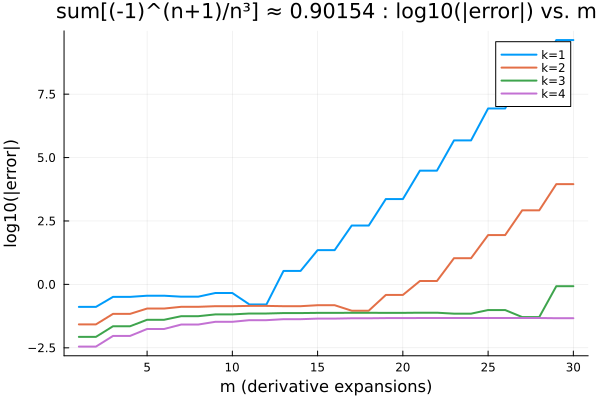

In [47]:
run_example(-cos(pi*x_)/x_^3, "sum[(-1)^(n+1)/n³] ≈ 0.90154", eta3_approx, true)

### Example 14: Catalan: ≈ 0.91597


=== run_example: Catalan: ≈ 0.91597

Catalan: ≈ 0.91597 => alt=true, k=1 => exact=0.915965594177219
| m | Approx | Error |
|---|---|---|
|  1 | 1.0185185185185186e+00 | 1.0255292434129959e-01 |
|  2 | 1.0185185185185186e+00 | 1.0255292434129959e-01 |
|  3 | 1.1683671596909553e+00 | 2.5240156551373627e-01 |
|  4 | 1.1683671596909553e+00 | 2.5240156551373627e-01 |
|  5 | 1.1879830022154558e+00 | 2.7201740803823682e-01 |
|  6 | 1.1879830022154558e+00 | 2.7201740803823682e-01 |
|  7 | 1.2826414910283384e+00 | 3.6667589685111934e-01 |
|  8 | 1.2826414910283384e+00 | 3.6667589685111934e-01 |
|  9 | 1.0891801118756999e+00 | 1.7321451769848084e-01 |
| 10 | 1.0891801118756999e+00 | 1.7321451769848084e-01 |
| 11 | 2.1461952769801460e+00 | 1.2302296828029271e+00 |
| 12 | 2.1461952769801504e+00 | 1.2302296828029315e+00 |
| 13 | -5.1922256997801135e+00 | 6.1081912939573328e+00 |
| 14 | -5.1922256997800966e+00 | 6.1081912939573160e+00 |
| 15 | 6.4282217538995127e+01 | 6.3366251944817911e+01 |
| 16 

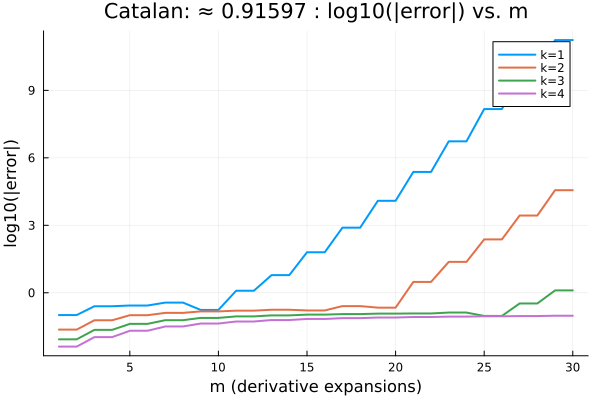

In [48]:
run_example(cos(pi*(x_-1))/(2*x_ - 1)^2, "Catalan: ≈ 0.91597", 0.915965594177219, true)

### Example 15: Arctan(1): π/4


=== run_example: Arctan(1): π/4

Arctan(1): π/4 => alt=true, k=1 => exact=0.7853981633974483
| m | Approx | Error |
|---|---|---|
|  1 | 9.4444444444444442e-01 | 1.5904628104699614e-01 |
|  2 | 9.4444444444444442e-01 | 1.5904628104699614e-01 |
|  3 | 1.1939087642277908e+00 | 4.0851060083034252e-01 |
|  4 | 1.1939087642277908e+00 | 4.0851060083034252e-01 |
|  5 | 1.4231307162444571e+00 | 6.3773255284700880e-01 |
|  6 | 1.4231307162444571e+00 | 6.3773255284700880e-01 |
|  7 | 1.6206966699498657e+00 | 8.3529850655241744e-01 |
|  8 | 1.6206966699498657e+00 | 8.3529850655241744e-01 |
|  9 | 1.7908047036835524e+00 | 1.0054065402861041e+00 |
| 10 | 1.7908047036835524e+00 | 1.0054065402861041e+00 |
| 11 | 1.9388886019372824e+00 | 1.1534904385398341e+00 |
| 12 | 1.9388886019372822e+00 | 1.1534904385398339e+00 |
| 13 | 2.0694333386982615e+00 | 1.2840351753008132e+00 |
| 14 | 2.0694333386982615e+00 | 1.2840351753008132e+00 |
| 15 | 2.1858676385682418e+00 | 1.4004694751707936e+00 |
| 16 | 2.18586

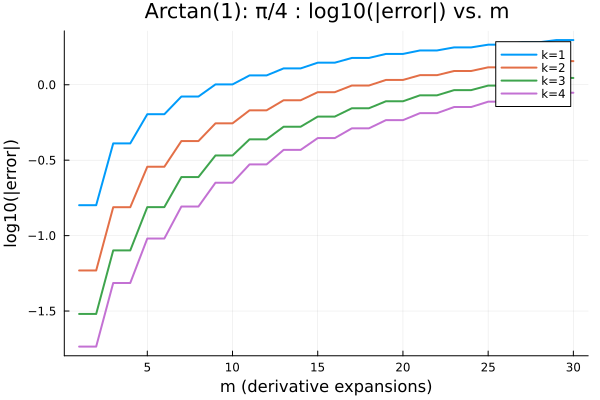

In [49]:
run_example(cos(pi*(x_-1))/(2*x_ - 1), "Arctan(1): π/4", float(pi/4), true)

### Example 16: sum[(-1)^n/√n] ≈ -0.60490


=== run_example: sum[(-1)^n/√n] ≈ -0.60490

sum[(-1)^n/√n] ≈ -0.60490 => alt=true, k=1 => exact=-0.6048986434
| m | Approx | Error |
|---|---|---|
|  1 | -7.3483495705504465e-01 | 1.2993631365504466e-01 |
|  2 | -7.3483495705504465e-01 | 1.2993631365504466e-01 |
|  3 | -9.4601912363373486e-01 | 3.4112048023373487e-01 |
|  4 | -9.4601912363373486e-01 | 3.4112048023373487e-01 |
|  5 | -1.2393279888594422e+00 | 6.3442934545944218e-01 |
|  6 | -1.2393279888594422e+00 | 6.3442934545944218e-01 |
|  7 | -1.5572582588688824e+00 | 9.5235961546888237e-01 |
|  8 | -1.5572582588688819e+00 | 9.5235961546888193e-01 |
|  9 | -1.8879657489092154e+00 | 1.2830671055092155e+00 |
| 10 | -1.8879657489092154e+00 | 1.2830671055092155e+00 |
| 11 | -2.2044947372753985e+00 | 1.5995960938753986e+00 |
| 12 | -2.2044947372753976e+00 | 1.5995960938753977e+00 |
| 13 | -2.5575444235084905e+00 | 1.9526457801084907e+00 |
| 14 | -2.5575444235084914e+00 | 1.9526457801084915e+00 |
| 15 | -2.6998436347069004e+00 | 2.09494

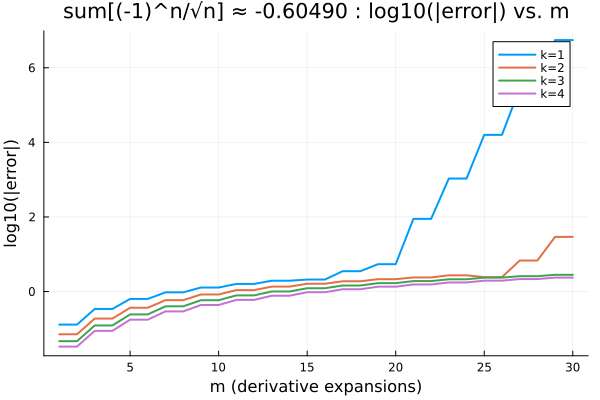

In [50]:
run_example(cos(pi*x_)/sqrt(x_), "sum[(-1)^n/√n] ≈ -0.60490", alt_sqrt_approx, true)

Illustrative examples : Displaying how the regularised EMSF and EBSF can give correct ramanujan constants cite chagas

In [51]:
# 10) Ramanujan constant for a general series
function ramanujan_constant(f::Sym, n_terms::Int)::Float64
    integral_val = Analytictail.safe_real_float(-SymPy.integrate(f, (Analytictail.x_, 0, 1)))
    f1_val = Analytictail.safe_real_float(f.subs(Analytictail.x_, 1)) / 2
    B = Analytictail.BernoulliListCached(2 * n_terms)
    sum_term = 0.0
    for k in 1:n_terms
        d_val = Analytictail.safe_real_float(diff(f, Analytictail.x_, 2*k - 1).subs(Analytictail.x_, 1))
        b_val = float(B[2*k+1])
        sum_term += b_val / float(factorial(2*k)) * d_val
    end
    return integral_val + f1_val - sum_term
end

# 11) Ramanujan constant for alternating series (wrapper)
function ramanujan_constant_alternating(f::Sym, n_terms::Int)::Float64
    return ramanujan_constant(f, n_terms)
end

# 12) Ramanujan constant for binary series
function ramanujan_constant_binary_series(base::BigFloat, n_terms::Int)::BigFloat
    log2 = log(base)
    log4 = log(BigFloat(4))
    
    integral_term = -1 / log4
    f1_term = BigFloat(1) / 4
    sum_term = BigFloat(0)
    
    B = Analytictail.BernoulliListCached(2 * n_terms)
    for k in 1:n_terms
        b_val = BigFloat(B[2*k+1])
        denom = BigFloat(factorial(2*k))
        # (log2)^(2*k-1) is computed with high-precision BigFloat arithmetic
        sum_term += b_val / denom * (log2^(2*k - 1)) / 2
    end
    
    return integral_term + f1_term + sum_term
end

# 13) Ramanujan constant for exponential series
function ramanujan_constant_exponential(base::Sym, offset::Int, n_terms::Int)::Float64
    # Define f(x) = base^(x + offset - 1)
    f = base^(Analytictail.x_ + offset - 1)
    
    integral_val = Analytictail.safe_real_float(-SymPy.integrate(f, (Analytictail.x_, 0, 1)))
    f1_val = Analytictail.safe_real_float(f.subs(Analytictail.x_, 1)) / 2
    
    B = Analytictail.BernoulliListCached(2 * n_terms)
    sum_term = 0.0
    for k in 1:n_terms
        # For this exponential f, the derivative at x = 1 is always 1.
        b_val = float(B[2*k+1])
        sum_term += b_val / float(factorial(2*k))
    end
    
    return integral_val + f1_val - sum_term
end

# 14) Ramanujan constant for Euler-type series
#     (accepting a vector of derivative functions)
function ramanujan_constant_euler(f::Function, derivatives::Vector{Function}, max_terms::Int=10)::Float64
    # f is a function (e.g. f(x)=1 or f(x)=x) taking a Float64 and returning a Float64.
    f1 = f(1.0)
    e_dict = Analytictail.euler_polynomials_cached(max_terms, 1.0)
    sum_term = 0.0
    for k in 1:max_terms
        d_val = derivatives[k](1.0)
        sum_term += e_dict[k] / factorial(k) * d_val
    end
    return f1 / 2 - sum_term / 2
end


ramanujan_constant_euler (generic function with 2 methods)

In [52]:
# Example: Ramanujan constant for a general series using f(x) = x^2
# (Also loop over f(x)=x^n for n = 1 to 10)

# Use the global symbol x_ from the module
f_general = x_^2
println("Ramanujan constant for f(x)=x^2: ", ramanujan_constant(f_general, 10))

println("\nn\tRamanujan constant for f(x)=x^n")
for n in 1:10
    f_power = x_^n
    rc = ramanujan_constant(f_power, 10)
    println("$(n)\t$(rc)")
end


Ramanujan constant for f(x)=x^2: 1.850371707708594e-17

n	Ramanujan constant for f(x)=x^n
1	-0.08333333333333333
2	1.850371707708594e-17
3	0.008333333333333333
4	-1.1102230246251566e-17
5	-0.003968253968253932
6	7.93016446160826e-18
7	0.004166666666666667
8	6.1679056923619804e-18
9	-0.007575757575757553
10	-3.027880976250427e-17


In [53]:
# Examples for alternating series (the alternating version simply calls ramanujan_constant)
using SymPy

# f(x) = -1 (constant alternating function)
f_alt1 = Sym(-1)
println("Ramanujan constant for alternating f(x) = -1: ", ramanujan_constant_alternating(f_alt1, 10))

# f(x) = -x (linear alternating function)
f_alt2 = -x_
println("Ramanujan constant for alternating f(x) = -x: ", ramanujan_constant_alternating(f_alt2, 10))

# f(x) = -x^3 (cubic alternating function)
f_alt3 = -x_^3
println("Ramanujan constant for alternating f(x) = -x^3: ", ramanujan_constant_alternating(f_alt3, 10))

# f(x) = -exp(x) (exponential alternating function)
f_alt4 = -exp(x_)
println("Ramanujan constant for alternating f(x) = -exp(x): ", ramanujan_constant_alternating(f_alt4, 10))

# f(x) = -2^(-x) (binary alternating function)
f_alt5 = -2^(-x_)
println("Ramanujan constant for alternating f(x) = -2^(-x): ", ramanujan_constant_alternating(f_alt5, 10))


Ramanujan constant for alternating f(x) = -1: 0.5
Ramanujan constant for alternating f(x) = -x: 0.08333333333333333
Ramanujan constant for alternating f(x) = -x^3: -0.008333333333333333
Ramanujan constant for alternating f(x) = -exp(x): 0.5819767068693266
Ramanujan constant for alternating f(x) = -2^(-x): 0.4426950408889634


In [54]:
# Example: Ramanujan constant for binary series
# Here we use BigFloat arithmetic for high-precision computation.
base_binary = BigFloat(2.0)
rc_binary = ramanujan_constant_binary_series(base_binary, 10)
println("Ramanujan constant for binary series (C(2^-n;0)) = ", rc_binary)
println("Ramanujan constant for binary series (rounded) = ", round(rc_binary, digits=10))


Ramanujan constant for binary series (C(2^-n;0)) = -0.4426950408889634073611609819841176758014401477298813902337679860020094358929399
Ramanujan constant for binary series (rounded) = -0.4426950409000000000000000000000000000000000000000000000000000000000000000000003


In [55]:
# Example: Ramanujan constant for exponential series
# Define e as a symbolic constant using SymPy.
E_sym = Sym(exp(1))

# Using offset 0: f(x) = e^(x-1)
offset1 = 0
rc_expo1 = ramanujan_constant_exponential(E_sym, offset1, 10)
println("Ramanujan constant for exponential series f(x)=e^(x-1): ", rc_expo1)

# Using offset 1: f(x) = e^x
offset2 = 1
rc_expo2 = ramanujan_constant_exponential(E_sym, offset2, 10)
println("Ramanujan constant for exponential series f(x)=e^x: ", rc_expo2)


Ramanujan constant for exponential series f(x)=e^(x-1): -0.2140972656978841
Ramanujan constant for exponential series f(x)=e^x: -0.44111762109884894


In [56]:
using SymPy
using SpecialFunctions
# Define the function f(x, α) symbolically
function f(x, α)
    return gamma(α + 1) / (gamma(x) * gamma(α - x + 2))
end

# Compute symbolic derivatives of f at x = 1
function compute_derivatives(α, max_order)
    x = symbols("x")  # Define the symbolic variable
    f_x = gamma(α + 1) / (gamma(x) * gamma(α - x + 2))  # Define f(x, α) symbolically

    # Compute derivatives of f at x = 1 and substitute x = 1 after each differentiation
    derivatives = [SymPy.diff(f_x, x, n).subs(Dict(x => 1)) for n in 1:max_order]
    return [N(deriv) for deriv in derivatives]  # Convert symbolic derivatives to numerical values
end

# Precomputed Euler polynomials E_k(1) / k! for k = 1, 3, 5 as used in the paper
euler_polys_at_1 = [1//2, -1//24, 1//240]  # E_1(1), E_3(1), and E_5(1)

# Compute the Ramanujan constant C(f) for a given α
function ramanujan_constant(α, max_order)
    f1 = f(1, α) / 2  # f(1)/2
    derivatives = compute_derivatives(α, max_order)  # Compute derivatives at x = 1

    # Calculate the sum of the terms in the Ramanujan constant formula up to max_order (using odd derivatives only)
    sum_term = sum(euler_polys_at_1[(k + 1) ÷ 2] * derivatives[k] for k in 1:2:max_order)
    return f1 - sum_term / 2
end

# Define the range of α values (from 1.0 down to -1.0, stepping by -0.1)
alphas = 1.0:-0.1:-1.0

# Set the maximum order of derivatives to compute (odd orders only: 1, 3, 5)
max_order = 5

# Print the Markdown table header
println("| α | C(f) | fhalf | f'(1) | f'''(1) | f^(5)(1) |")
println("|---|------|-------|-------|---------|----------|")

# Generate the table rows
for α in alphas
    C_f = ramanujan_constant(α, max_order)
    fhalf = f(1, α) / 2
    derivatives = compute_derivatives(α, max_order)
    f1_prime = derivatives[1]
    f3_prime = max_order >= 3 ? derivatives[3] : "N/A"
    f5_prime = max_order >= 5 ? derivatives[5] : "N/A"
    println("| $(α) | $(C_f) | $(fhalf) | $(f1_prime) | $(f3_prime) | $(f5_prime) |")
end


| α | C(f) | fhalf | f'(1) | f'''(1) | f^(5)(1) |
|---|------|-------|-------|---------|----------|
| 1.0 | 0.12768115203518987 | 0.5 | 1.0 | -3.8696044010893584 | 20.017003012215266 |
| 0.9 | 0.14600461011504667 | 0.5 | 0.9333998260655925 | -3.7735907095807613 | 20.173900921098888 |
| 0.8 | 0.1667495743196461 | 0.5 | 0.8622070981953944 | -3.6398806970874595 | 20.09654557224793 |
| 0.7 | 0.1903225224833306 | 0.5 | 0.785763539775027 | -3.462293697172905 | 19.730627463269023 |
| 0.6 | 0.21722518754867637 | 0.5 | 0.7032631176750092 | -3.233214142245562 | 19.008194433178648 |
| 0.5 | 0.24808489044222598 | 0.5 | 0.6137056388801094 | -2.9431361355960757 | 17.84321456615764 |
| 0.4 | 0.2836975015082749 | 0.5 | 0.5158311203164166 | -2.580018636898574 | 16.125278469072338 |
| 0.3 | 0.32508971245105656 | 0.5 | 0.40802477603473297 | -2.128351096624178 | 13.710453933083112 |
| 0.2 | 0.37361171004463034 | 0.5 | 0.2881757683093449 | -1.5677632879673673 | 10.407654101782397 |
| 0.1 | 0.43107933901103

| α | C(f) | fhalf | f'(1) | f'''(1) | f^(5)(1) |
|---|------|-------|-------|---------|----------|
| 1.0 | 0.12768115203518987 | 0.5 | 1.0 | -3.8696044010893584 | 20.017003012215266 |
| 0.9 | 0.14600461011504667 | 0.5 | 0.9333998260655925 | -3.7735907095807613 | 20.173900921098888 |
| 0.8 | 0.1667495743196461 | 0.5 | 0.8622070981953944 | -3.6398806970874595 | 20.09654557224793 |
| 0.7 | 0.1903225224833306 | 0.5 | 0.785763539775027 | -3.462293697172905 | 19.730627463269023 |
| 0.6 | 0.21722518754867637 | 0.5 | 0.7032631176750092 | -3.233214142245562 | 19.008194433178648 |
| 0.5 | 0.24808489044222598 | 0.5 | 0.6137056388801094 | -2.9431361355960757 | 17.84321456615764 |
| 0.4 | 0.2836975015082749 | 0.5 | 0.5158311203164166 | -2.580018636898574 | 16.125278469072338 |
| 0.3 | 0.32508971245105656 | 0.5 | 0.40802477603473297 | -2.128351096624178 | 13.710453933083112 |
| 0.2 | 0.37361171004463034 | 0.5 | 0.2881757683093449 | -1.5677632879673673 | 10.407654101782397 |
| 0.1 | 0.4310793390110344 | 0.5 | 0.15346072449045617 | -0.8708932413869716 | 5.957697921979036 |
| 0.0 | 0.5 | 0.5 | 0 | 0 | -3.121172945022325e-15 |
| -0.1 | 0.5839467880331373 | 0.4999999999999999 | -0.17771128504551867 | 1.0986455897245184 | -7.982648153198491 |
| -0.2 | 0.6882095776222718 | 0.5 | -0.3877929018046055 | 2.5045210185553066 | -18.760238856584696 |
| -0.3 | 0.8209983239683541 | 0.5 | -0.6428078887964019 | 4.340888688137572 | -33.53336196786606 |
| -0.4 | 0.9958399146279797 | 0.5000000000000001 | -0.9634035489916573 | 6.810720594208602 | -54.28752720034529 |
| -0.5 | 1.2368342042852427 | 0.5 | -1.3862943611198906 | 10.2754738016019 | -84.57035670651067 |
| -0.6 | 1.591762374059977 | 0.4999999999999999 | -1.9841688796835835 | 15.45154820828344 | -131.43019190392448 |
| -0.7 | 2.171347356244473 | 0.5 | -2.9253085572985995 | 23.998681743242354 | -211.22288668909138 |
| -0.8 | 3.3061429375984526 | 0.5 | -4.711824231690657 | 40.87122669450251 | -372.8174352993532 |
| -0.9 | 6.644260968812717 | 0.5000000000000006 | -9.846539275509546 | 90.76959746900877 | -859.9645772788707 |
| -1.0 | NaN | NaN | NaN | NaN | NaN |